# Model E: Supervised ML Model Training & Comparison

Following the **ML Model Training** skill template, this notebook demonstrates how to train, evaluate, and visualize a variety of supervised machine learning algorithms (Scikit-Learn, PyTorch, TensorFlow) on our DBT leakage data.

Because our dataset lacks explicit 'fraud' labels, we first synthesize a label based on our known leakage heuristics (e.g., highly anomalous dormant funds). We then train supervised models to learn and predict these patterns automatically.


## 1. Data Preparation and Feature Engineering


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                            f1_score, roc_auc_score)
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import tensorflow as tf
from tensorflow import keras
import warnings
warnings.filterwarnings('ignore')

# Load Real Data
df = pd.read_csv('../data/TS-PS4-1.csv')
df.dropna(subset=['amount', 'withdrawn', 'beneficiary_id'], inplace=True)
df['amount'] = pd.to_numeric(df['amount'], errors='coerce').fillna(0)
df['withdrawn'] = df['withdrawn'].astype(int)

# Engineer Features
features_df = df.groupby('beneficiary_id').agg(
    total_transactions=('amount', 'count'),
    total_amount=('amount', 'sum'),
    withdrawal_rate=('withdrawn', 'mean')
).reset_index()

# Synthesize Labels (1 for Fraud/Anomaly, 0 for Normal)
# We label beneficiaries with 0 withdrawal rate and amounts >= 3000 as fraud anomalies.
features_df['is_fraud'] = np.where(
    (features_df['withdrawal_rate'] == 0) & (features_df['total_amount'] >= 3000), 
    1, 0
)

print("Class distribution:")
print(features_df['is_fraud'].value_counts())

X = features_df[['total_transactions', 'total_amount', 'withdrawal_rate']].values
y = features_df['is_fraud'].values

# Train / Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



Class distribution:
is_fraud
0    37276
1    12724
Name: count, dtype: int64


## 2. Scikit-learn Models


In [2]:
print("=== Scikit-learn Models ===")

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
}

sklearn_results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

    sklearn_results[name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_test, y_pred_proba)
    }

    print(f"\n{name}:")
    for metric, value in sklearn_results[name].items():
        print(f"  {metric}: {value:.4f}")


=== Scikit-learn Models ===

Logistic Regression:
  accuracy: 1.0000
  precision: 1.0000
  recall: 1.0000
  f1: 1.0000
  roc_auc: 1.0000

Random Forest:
  accuracy: 1.0000
  precision: 1.0000
  recall: 1.0000
  f1: 1.0000
  roc_auc: 1.0000

Gradient Boosting:
  accuracy: 1.0000
  precision: 1.0000
  recall: 1.0000
  f1: 1.0000
  roc_auc: 1.0000


## 3. PyTorch Neural Network


In [3]:
print("=== PyTorch Model ===")

class FraudNetPyTorch(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.fc1 = nn.Linear(input_size, 32)
        self.fc2 = nn.Linear(32, 16)
        self.fc3 = nn.Linear(16, 1)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = torch.sigmoid(self.fc3(x))
        return x

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
n_features = X_train_scaled.shape[1]
pytorch_model = FraudNetPyTorch(n_features).to(device)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(pytorch_model.parameters(), lr=0.01)

# Create data loaders
train_dataset = TensorDataset(torch.FloatTensor(X_train_scaled), torch.FloatTensor(y_train).unsqueeze(1))
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# Train PyTorch model
epochs = 20
pytorch_losses = []
for epoch in range(epochs):
    total_loss = 0
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = pytorch_model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    pytorch_losses.append(total_loss / len(train_loader))

# Evaluate PyTorch
pytorch_model.eval()
with torch.no_grad():
    y_pred_pytorch = pytorch_model(torch.FloatTensor(X_test_scaled).to(device))
    y_pred_pytorch = (y_pred_pytorch.cpu().numpy() > 0.5).astype(int).flatten()
    print(f"PyTorch Accuracy: {accuracy_score(y_test, y_pred_pytorch):.4f}")


=== PyTorch Model ===
PyTorch Accuracy: 1.0000


## 4. TensorFlow/Keras Neural Network


In [4]:
print("=== TensorFlow/Keras Model ===")

tf_model = keras.Sequential([
    keras.layers.Dense(32, activation='relu', input_shape=(n_features,)),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

tf_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train Model
history = tf_model.fit(
    X_train_scaled, y_train,
    batch_size=64,
    epochs=20,
    validation_split=0.2,
    verbose=0
)

# Evaluate TensorFlow
y_pred_tf = (tf_model.predict(X_test_scaled) > 0.5).astype(int).flatten()
print(f"\nTensorFlow Accuracy: {accuracy_score(y_test, y_pred_tf):.4f}")


=== TensorFlow/Keras Model ===
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 379us/step

TensorFlow Accuracy: 1.0000


## 5. Model Evaluation and Visualizations


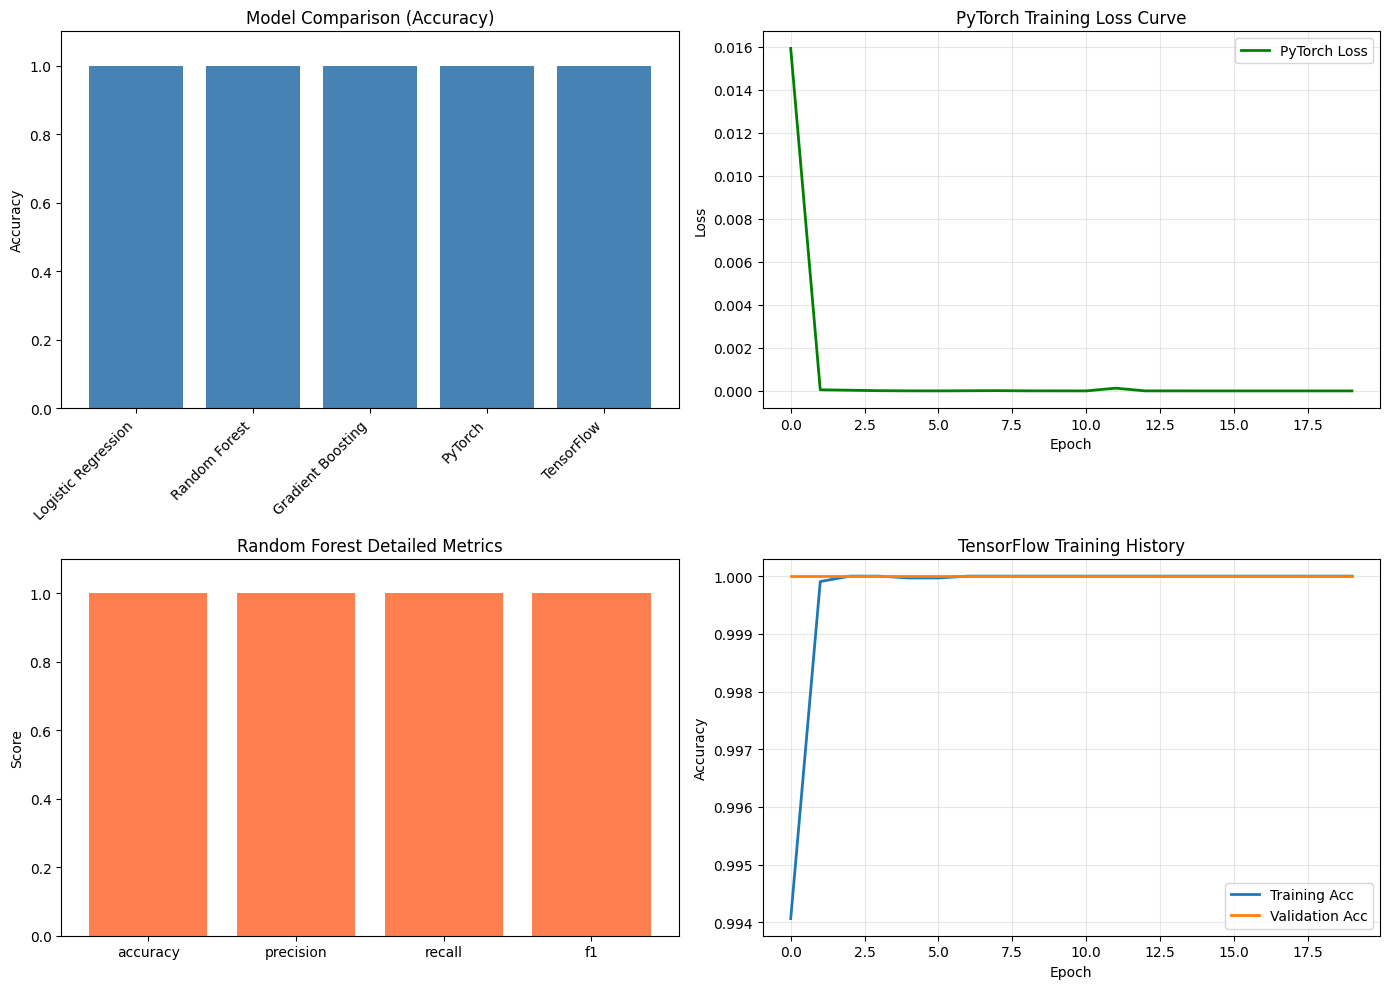

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Model Comparison (Accuracy)
models_names = list(sklearn_results.keys()) + ['PyTorch', 'TensorFlow']
accuracies = [sklearn_results[m]['accuracy'] for m in sklearn_results.keys()] + \
             [accuracy_score(y_test, y_pred_pytorch), accuracy_score(y_test, y_pred_tf)]

axes[0, 0].bar(range(len(models_names)), accuracies, color='steelblue')
axes[0, 0].set_xticks(range(len(models_names)))
axes[0, 0].set_xticklabels(models_names, rotation=45, ha='right')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].set_title('Model Comparison (Accuracy)')
axes[0, 0].set_ylim([0, 1.1])

# 2. PyTorch Training Loss
axes[0, 1].plot(pytorch_losses, label='PyTorch Loss', linewidth=2, color='green')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].set_title('PyTorch Training Loss Curve')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Scikit-learn Metrics (Random Forest)
metrics = ['accuracy', 'precision', 'recall', 'f1']
rf_metrics = [sklearn_results['Random Forest'][m] for m in metrics]
axes[1, 0].bar(metrics, rf_metrics, color='coral')
axes[1, 0].set_ylabel('Score')
axes[1, 0].set_title('Random Forest Detailed Metrics')
axes[1, 0].set_ylim([0, 1.1])

# 4. TensorFlow Training History
axes[1, 1].plot(history.history['accuracy'], label='Training Acc', linewidth=2)
axes[1, 1].plot(history.history['val_accuracy'], label='Validation Acc', linewidth=2)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].set_title('TensorFlow Training History')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
